In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
# Load all predictions CV for all the models here 
LSTM_PRED_PATH = "../forecast evaluations/lstm_outputs/lstm_rolling_oos_predictions.csv"
HAR_PRED_PATH  = "../forecast evaluations/har_outputs/har_family_rolling_oos_predictions.csv"
LASSO_PRED_PATH = "../forecast evaluations/lasso_outputs/lasso_rolling_oos_predictions.csv"
RIDGE_PRED_PATH = "../forecast evaluations/ridge_outputs/ridge_rolling_oos_predictions.csv"
SVR_PRED_PATH = "../forecast evaluations/svr_outputs/svr_rolling_oos_predictions.csv"
XGB_PRED_PATH = "../forecast evaluations/xgb_outputs/xgb_rolling_oos_predictions.csv"
RF_PRED_PATH = "../forecast evaluations/rf_outputs/rf_rolling_oos_predictions.csv"

OUT_DIR = "../figs/all_models"
os.makedirs(OUT_DIR, exist_ok=True)

HORIZONS = [1, 3, 5, 7]


In [3]:
# ---------- LOAD + STANDARDIZE LSTM ----------
lstm = pd.read_csv(LSTM_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
lstm["date"] = pd.to_datetime(lstm["date"], dayfirst=True, errors="raise")

# ensure correct types
lstm["h"] = lstm["h"].astype(int)

# create model column so it matches HAR format
if "model" not in lstm.columns:
    lstm["model"] = "LSTM"

print(lstm.head(3))

        date  h    y_true    y_pred     error model
0 2024-06-29  1 -8.047432 -8.477390  0.429958  LSTM
1 2024-06-30  1 -8.009439 -7.950675 -0.058764  LSTM
2 2024-07-01  1 -8.415744 -7.934552 -0.481192  LSTM


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/3870242691.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  lstm["date"] = pd.to_datetime(lstm["date"], dayfirst=True, errors="raise")


In [4]:
# ---------- LOAD + STANDARDIZE HAR ----------
har = pd.read_csv(HAR_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
har["date"] = pd.to_datetime(har["date"], dayfirst=True, errors="raise")

print(har.head(3))

        date   model  h    y_true    y_pred     error
0 2024-06-29  HAR-RV  1 -8.047432 -7.808740 -0.238692
1 2024-06-30  HAR-RV  1 -8.009439 -8.165342  0.155903
2 2024-07-01  HAR-RV  1 -8.415744 -8.018623 -0.397121


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/2327861109.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  har["date"] = pd.to_datetime(har["date"], dayfirst=True, errors="raise")


In [5]:
# ---------- LOAD + STANDARDIZE LASSO ----------
lasso = pd.read_csv(LASSO_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
lasso["date"] = pd.to_datetime(lasso["date"], dayfirst=True, errors="raise")

print(lasso.head(3))

        date  model  h    y_true    y_pred     error
0 2024-06-29  LASSO  1 -8.047432 -8.469853  0.422421
1 2024-06-30  LASSO  1 -8.009439 -7.834672 -0.174767
2 2024-07-01  LASSO  1 -8.415744 -8.010187 -0.405557


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/3771399679.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  lasso["date"] = pd.to_datetime(lasso["date"], dayfirst=True, errors="raise")


In [6]:
# ---------- LOAD + STANDARDIZE RIDGE ----------
ridge = pd.read_csv(RIDGE_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
ridge["date"] = pd.to_datetime(ridge["date"], dayfirst=True, errors="raise")

print(ridge.head(3))

        date  model  h    y_true    y_pred     error
0 2024-06-29  RIDGE  1 -8.047432 -8.333578  0.286146
1 2024-06-30  RIDGE  1 -8.009439 -7.785088 -0.224350
2 2024-07-01  RIDGE  1 -8.415744 -8.046267 -0.369478


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/2970138733.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  ridge["date"] = pd.to_datetime(ridge["date"], dayfirst=True, errors="raise")


In [7]:
# ---------- LOAD + STANDARDIZE SVR ----------
svr = pd.read_csv(SVR_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
svr["date"] = pd.to_datetime(svr["date"], dayfirst=True, errors="raise")

print(svr.head(3))

        date model  h    y_true    y_pred     error
0 2024-06-29   SVR  1 -8.047432 -8.309722  0.262290
1 2024-06-30   SVR  1 -8.009439 -7.831747 -0.177692
2 2024-07-01   SVR  1 -8.415744 -8.095338 -0.320406


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/2985874676.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  svr["date"] = pd.to_datetime(svr["date"], dayfirst=True, errors="raise")


In [8]:
# ---------- LOAD + STANDARDIZE XGB ----------
xgb = pd.read_csv(XGB_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
xgb["date"] = pd.to_datetime(xgb["date"], dayfirst=True, errors="raise")

print(xgb.head(3))

        date    model  h    y_true    y_pred     error
0 2024-06-29  XGBoost  1 -8.047432 -8.409252  0.361820
1 2024-06-30  XGBoost  1 -8.009439 -7.319297 -0.690142
2 2024-07-01  XGBoost  1 -8.415744 -7.441876 -0.973868


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/283626033.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  xgb["date"] = pd.to_datetime(xgb["date"], dayfirst=True, errors="raise")


In [9]:
# ---------- LOAD + STANDARDIZE RF ----------
rf = pd.read_csv(RF_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
rf["date"] = pd.to_datetime(rf["date"], dayfirst=True, errors="raise")

print(rf.head(3))

        date         model  h    y_true    y_pred     error
0 2024-06-29  RandomForest  1 -8.047432 -8.515202  0.467770
1 2024-06-30  RandomForest  1 -8.009439 -7.856562 -0.152877
2 2024-07-01  RandomForest  1 -8.415744 -7.629252 -0.786492


/var/folders/bg/l87j9pbx62sbccfkfg4fknp40000gn/T/ipykernel_44513/2352989160.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  rf["date"] = pd.to_datetime(rf["date"], dayfirst=True, errors="raise")


In [10]:
# Combine dataframe 
preds = pd.concat([lstm, har, svr, lasso, ridge, xgb, rf], ignore_index=True)

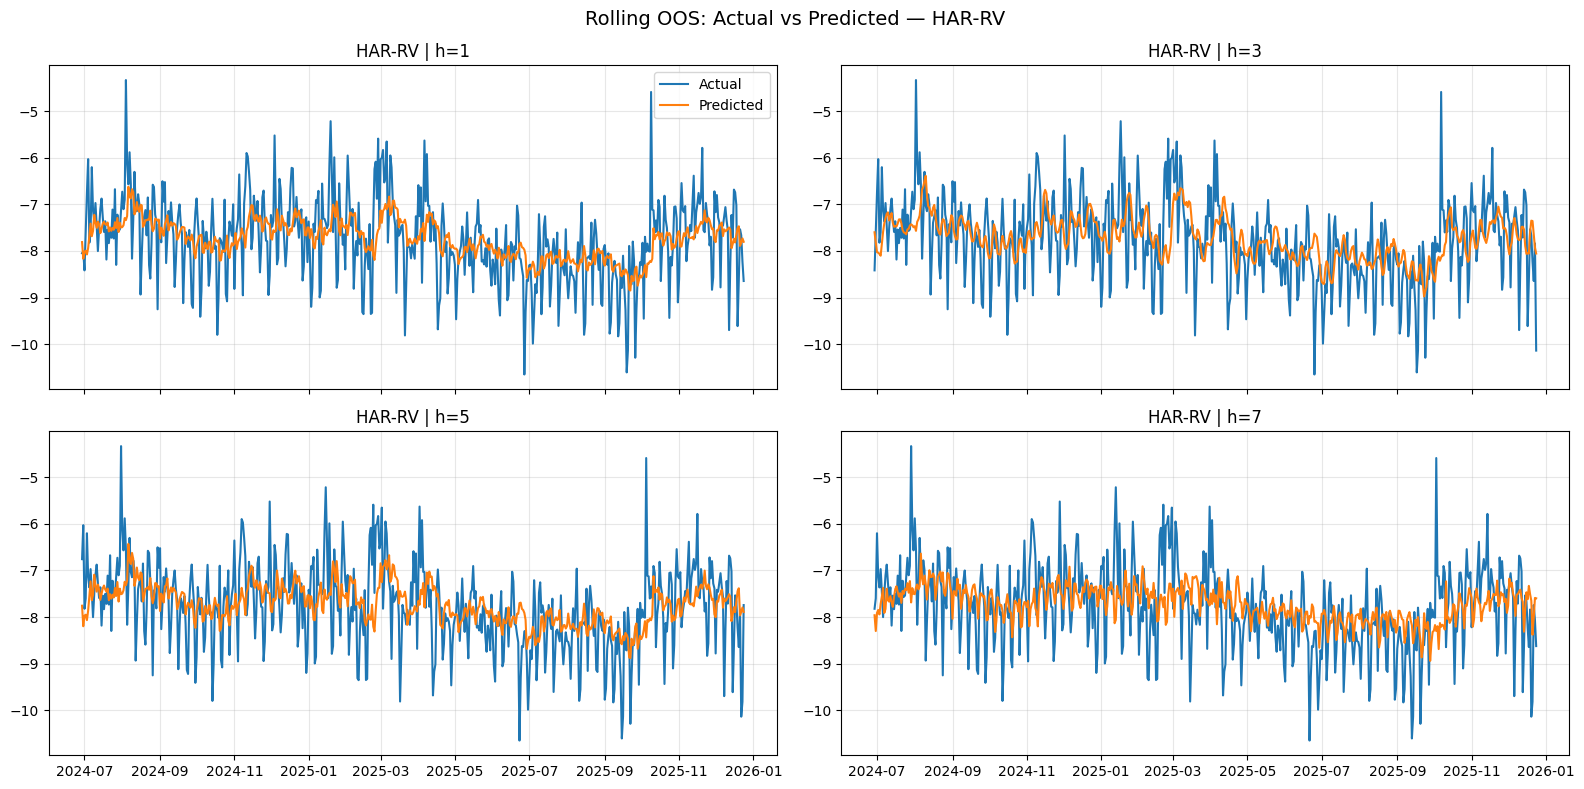

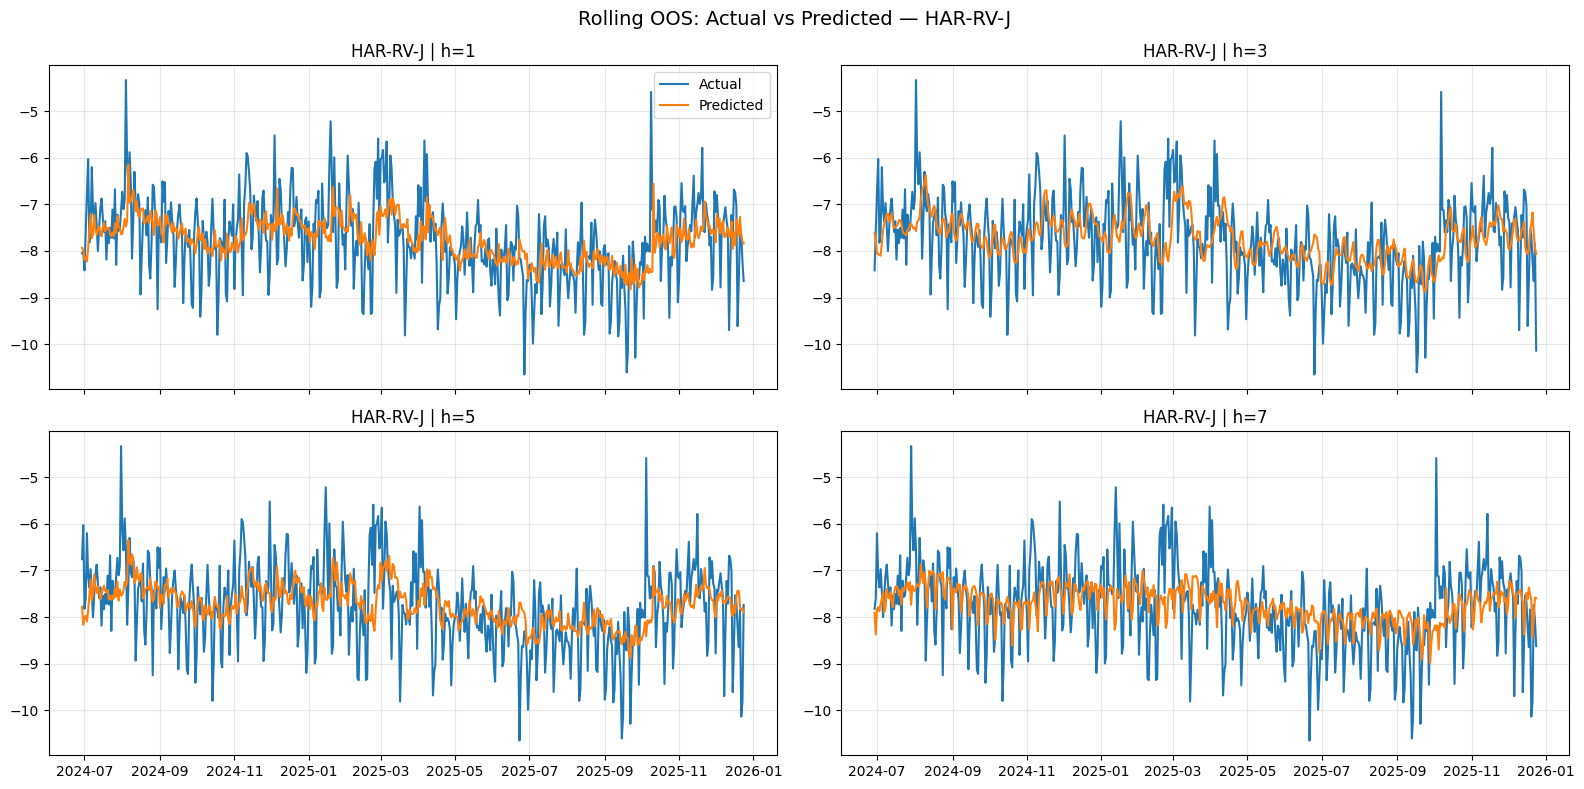

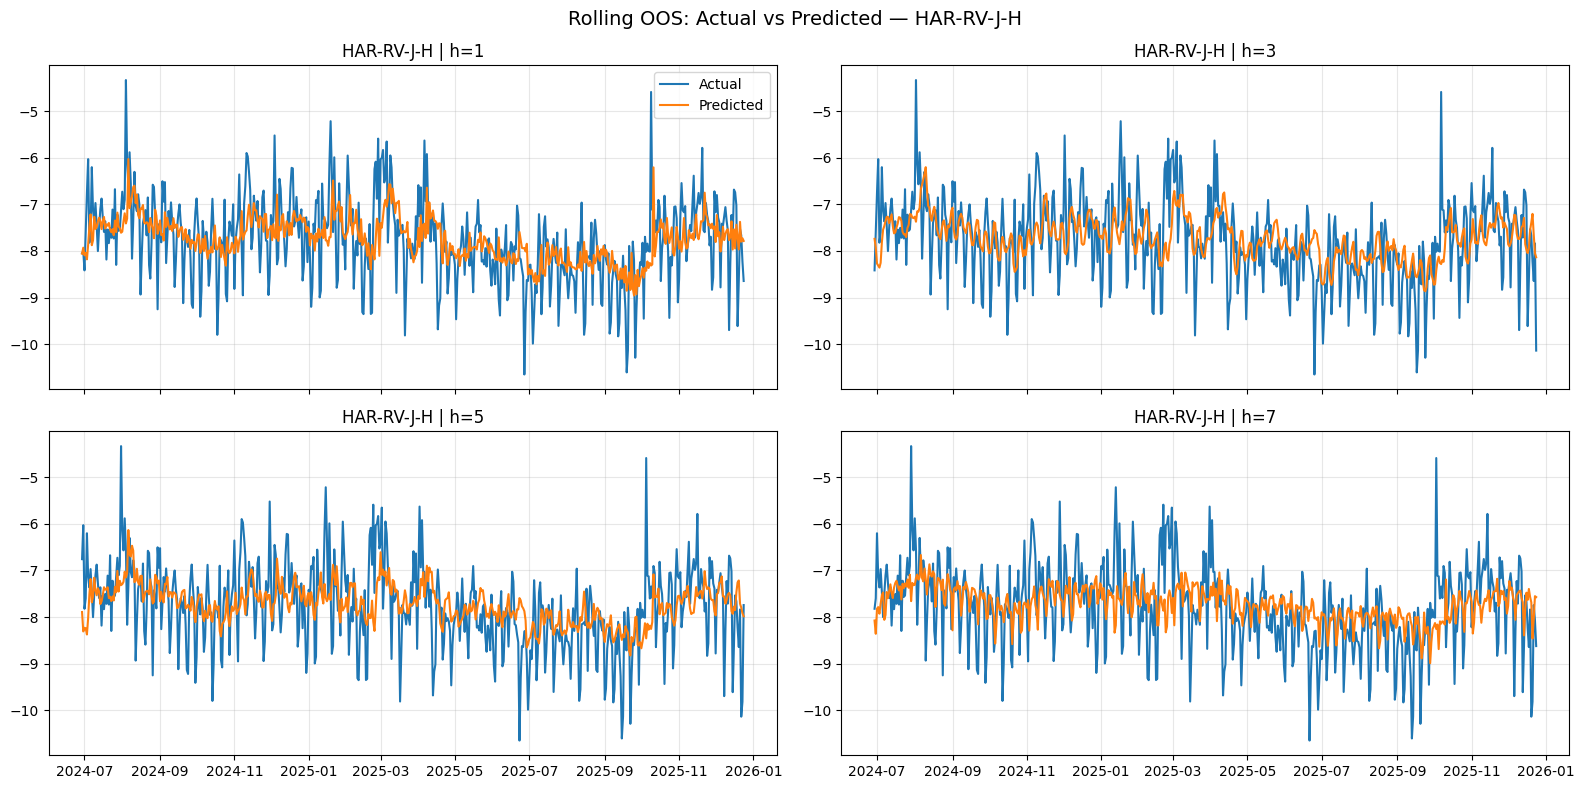

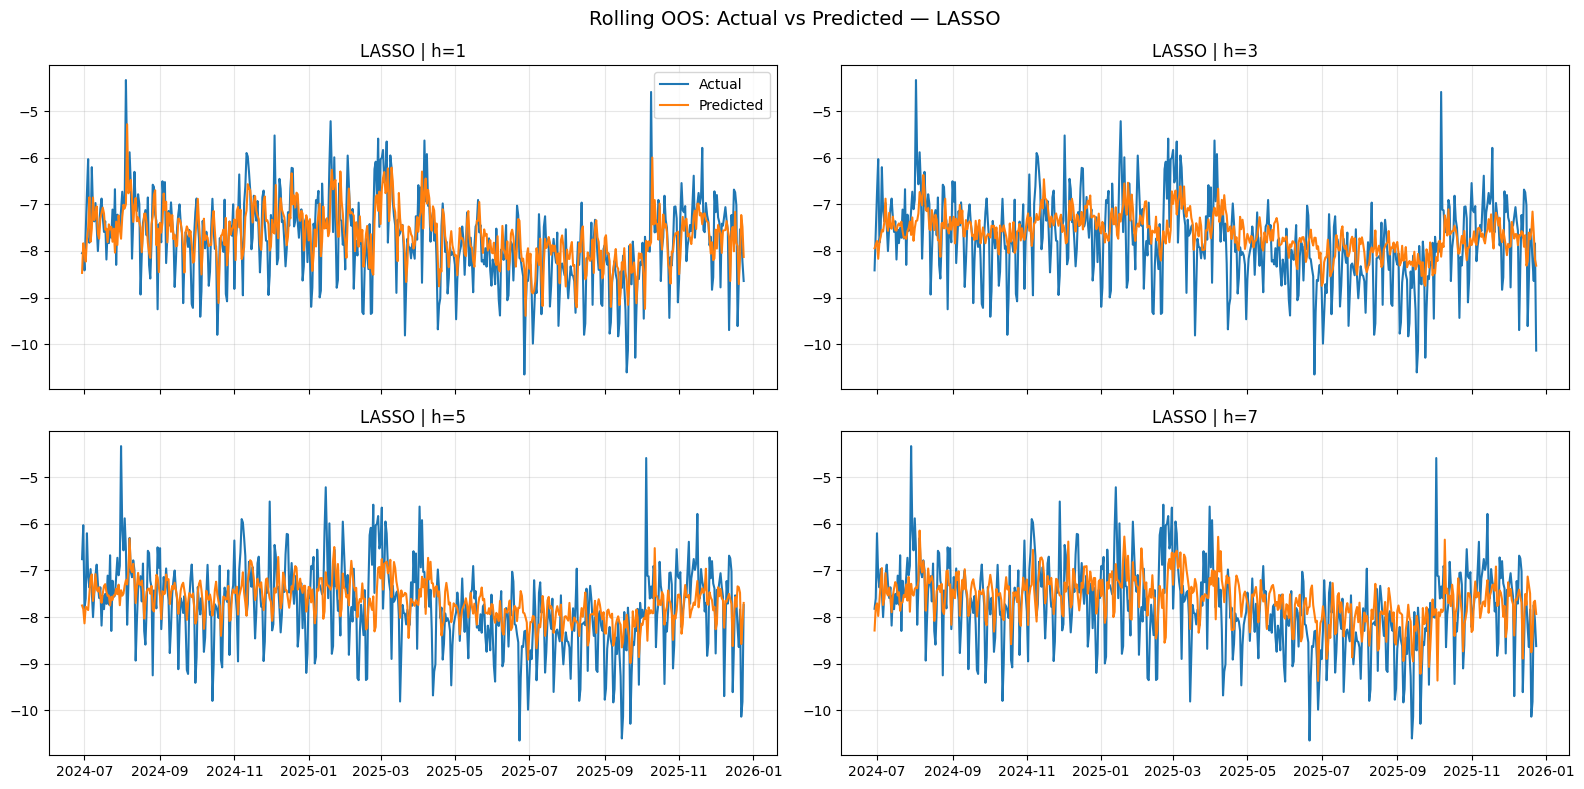

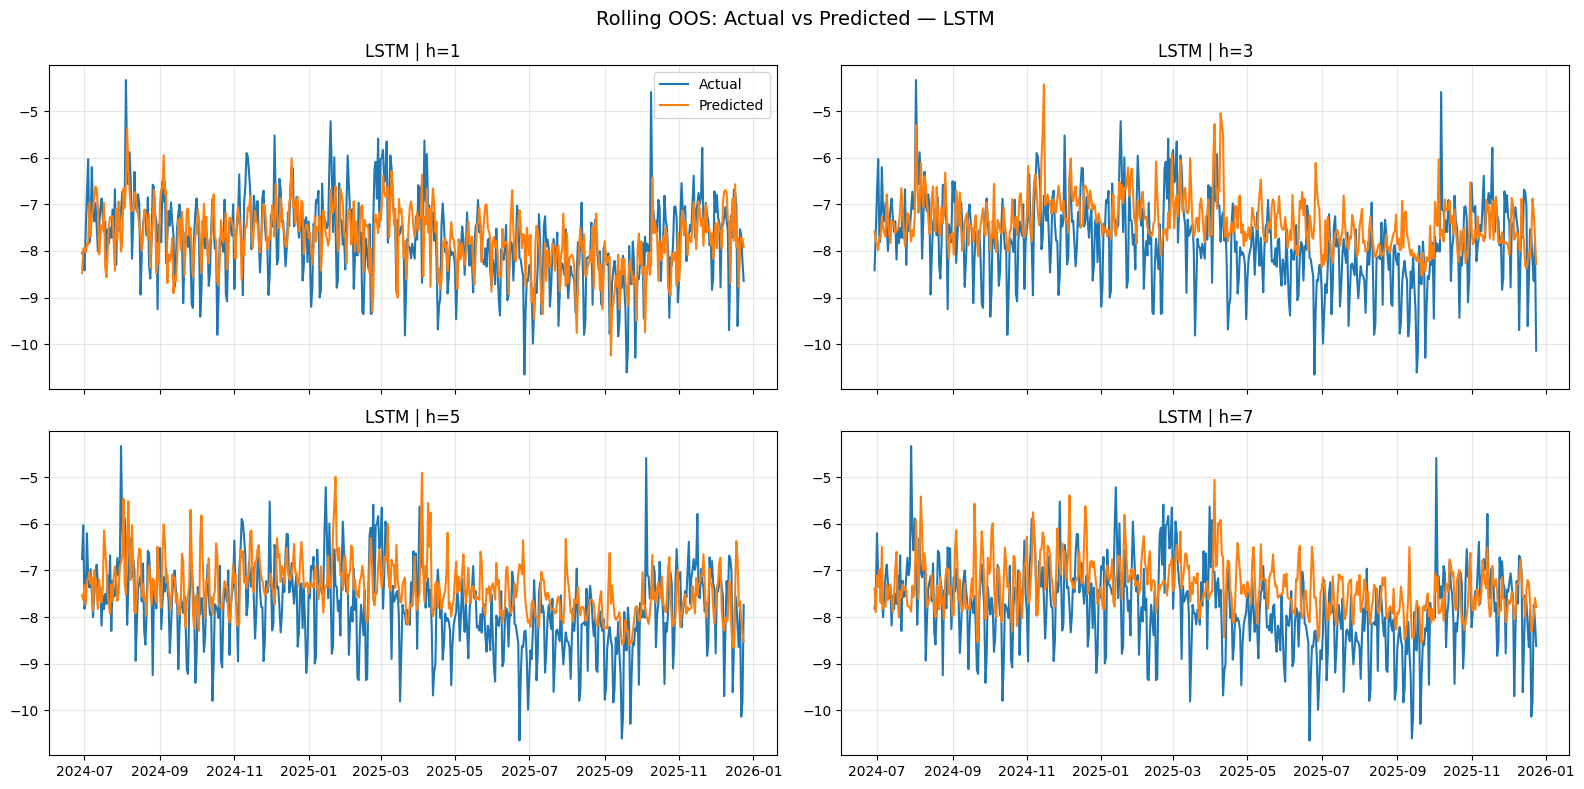

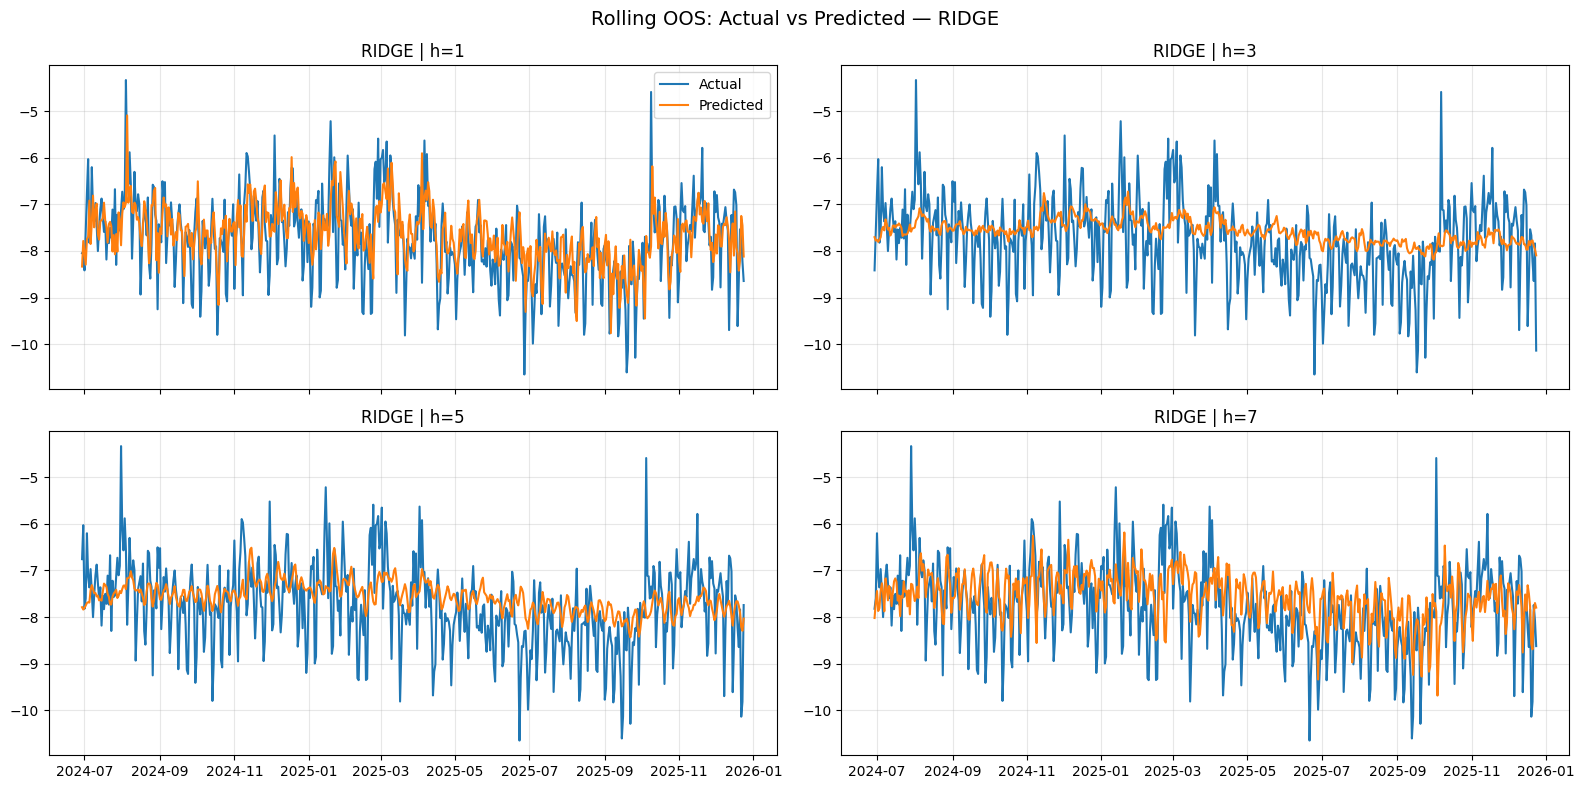

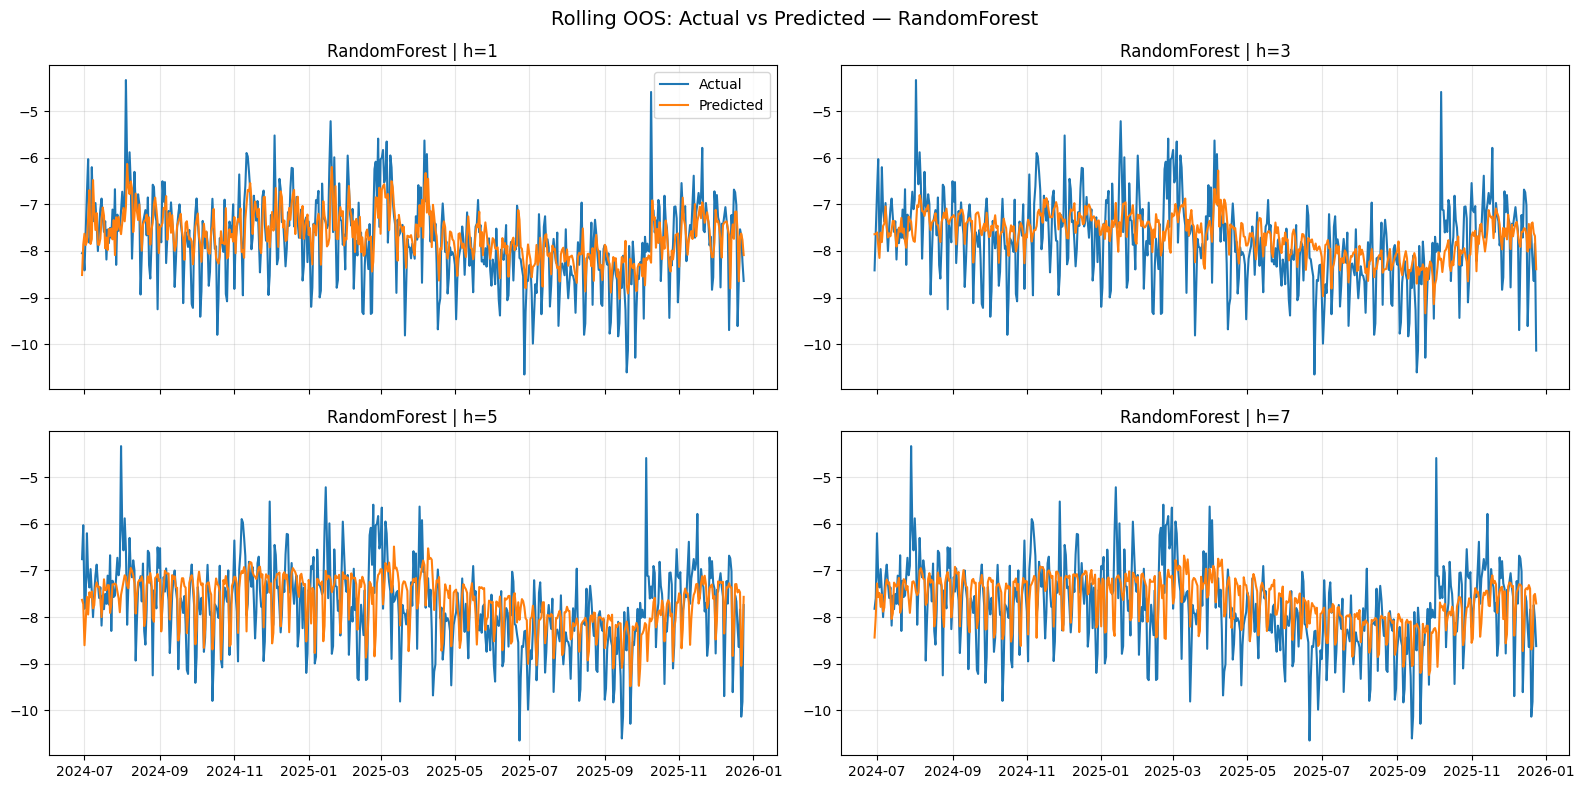

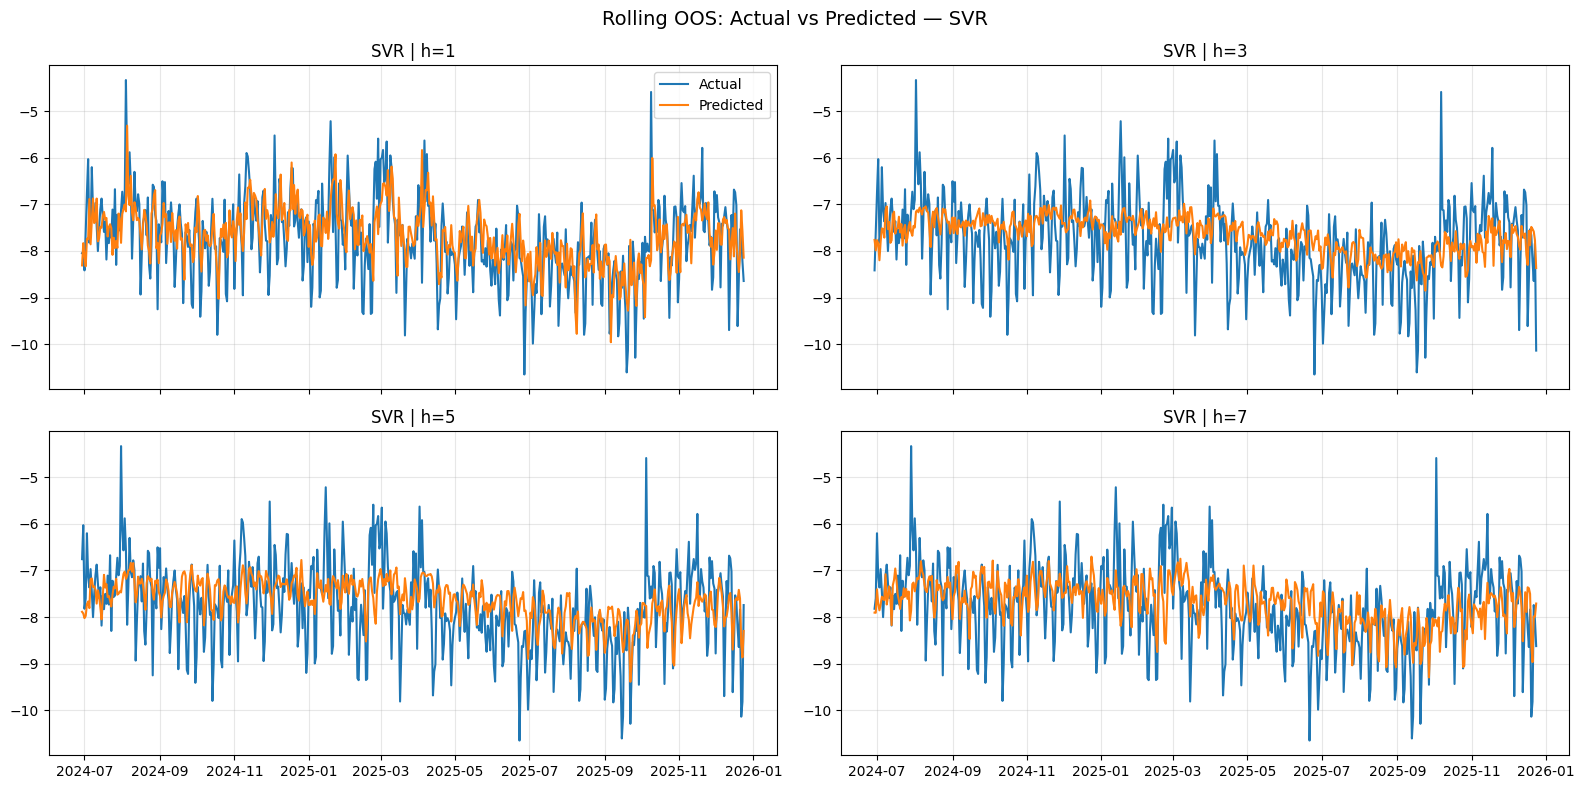

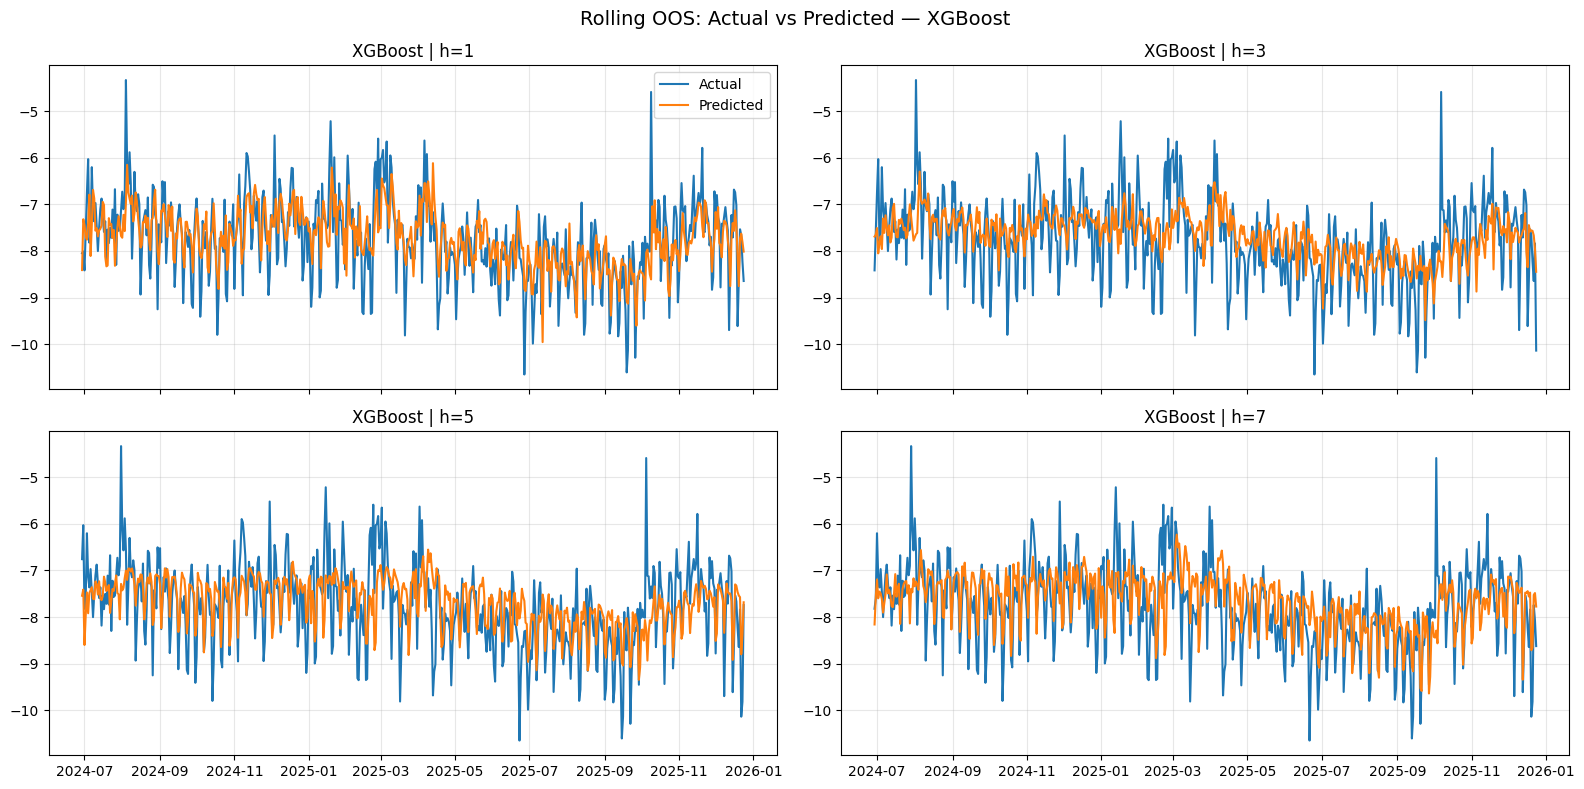

Saved all plots to: ../figs/all_models


In [11]:
# ---------- PLOT: one 2x2 figure per model ----------
models = sorted(preds["model"].unique())

for model_name in models:
    fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
    axes = axes.flatten()

    for ax, h in zip(axes, HORIZONS):
        df_mh = preds[(preds["model"] == model_name) & (preds["h"] == h)].sort_values("date")

        if df_mh.empty:
            ax.set_title(f"{model_name} | h={h} (no data)")
            ax.axis("off")
            continue

        ax.plot(df_mh["date"], df_mh["y_true"], label="Actual", linewidth=1.5)
        ax.plot(df_mh["date"], df_mh["y_pred"], label="Predicted", linewidth=1.5)
        ax.set_title(f"{model_name} | h={h}")
        ax.grid(alpha=0.3)

    # one legend for the whole figure
    axes[0].legend(loc="upper right")

    fig.suptitle(f"Rolling OOS: Actual vs Predicted — {model_name}", fontsize=14)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"{model_name}_actual_vs_pred_2x2.png")
    plt.savefig(out_path, dpi=200)
    plt.show()

print(f"Saved all plots to: {OUT_DIR}")